# PX4 Phase 1 Task-Aware PINN Rollout Simulator v1

This notebook uses the fixed PX4 closed-loop tracking-error PINN as a task-level rollout simulator.

Goal:

```text
Task sequence -> guidance setpoints -> PINN rollout -> ETA / tracking error / risk / mission cost
```

Scope: multicopter closed-loop mode only. Fixed-wing/transition mode is intentionally left for the next phase.


In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print('Drive mount skipped:', type(exc).__name__, exc)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import glob
import json
import math
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)


device: cuda
torch: 2.10.0+cu128


In [3]:
NOTEBOOK_REVISION = 'task_aware_pinn_rollout_simulator_v1'
MANUAL_CHECKPOINT_PATH = ''
MANUAL_DATASET_DIR = ''
CHECKPOINT_GLOBS = [
    '/content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_tracking_error_training_v18/**/px4_tracking_error_dynamics_pinn_v18.pt',
    '/content/drive/MyDrive/**/px4_tracking_error_dynamics_pinn_v18.pt',
    '/content/**/px4_tracking_error_dynamics_pinn_v18.pt',
]
DATASET_GLOBS = [
    '/content/drive/MyDrive/**/px4_phase1_recovery_tracking_error_dataset_v9_*',
    '/content/drive/MyDrive/**/processed/px4_phase1_recovery_tracking_error_dataset_v9_*',
    '/content/**/px4_phase1_recovery_tracking_error_dataset_v9_*',
]

DT = 0.05
TARGET_ALT_M = 25.0
ALT_MIN_M = 15.0
ALT_MAX_M = 35.0
POS_LIMIT_M = 6.0
VEL_LIMIT_M_S = 0.65
VD_LIMIT_M_S = 0.35
YAW_OFFSET_LIMIT_DEG = 25.0

# Guidance gains are deliberately simple; this is a mission-level simulator,
# not a replacement for PX4's internal controller.
GUIDANCE_KP_POS = 0.45
GUIDANCE_KP_ALT = 0.28
GUIDANCE_KP_YAW = 0.35
GUIDANCE_MAX_VXY_M_S = 0.55
GUIDANCE_MAX_VD_M_S = 0.25

USE_TASK_STATE_PLANNING = True
ATTITUDE_PROJECTION_CLIP_DEG = 0.25
RATE_PROJECTION_CLIP_RAD_S = 0.02
HOVER_STATE = None
HOVER_ACTION = None
BEST_HOVER_LABEL = 'target_aligned'

COMPLETION_POS_TOL_M = 0.35
COMPLETION_ALT_TOL_M = 0.35
COMPLETION_YAW_TOL_DEG = 4.0
COMPLETION_SPEED_TOL_M_S = 0.35
COMPLETION_HOLD_S = 1.0
MAX_ROLLOUT_S = 90.0

MISSION_COST = dict(
    eta=1.0,
    pos_rmse=8.0,
    alt_rmse=6.0,
    yaw_rmse=0.20,
    max_deviation=4.0,
    risk=25.0,
    energy=2.0,
)


In [4]:
def find_checkpoint():
    if MANUAL_CHECKPOINT_PATH:
        p = Path(MANUAL_CHECKPOINT_PATH)
        if p.exists():
            return p
        raise FileNotFoundError(f'MANUAL_CHECKPOINT_PATH not found: {p}')
    matches = []
    for pat in CHECKPOINT_GLOBS:
        matches.extend(Path(x) for x in glob.glob(pat, recursive=True))
    matches = sorted(set(p for p in matches if p.exists()))
    if not matches:
        raise FileNotFoundError('No v18 tracking-error PINN checkpoint found. Run the v18 training notebook first or set MANUAL_CHECKPOINT_PATH.')
    return matches[-1]

CKPT_PATH = find_checkpoint()
print('CKPT_PATH:', CKPT_PATH)
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
print('revision:', ckpt.get('revision'))
print('dataset:', ckpt.get('dataset_dir'))
STATE_COLS = ckpt['state_cols']
ACTION_COLS = ckpt['action_cols']
TARGET_COLS = ckpt['target_cols']
FEATURE_COLS = ckpt['feature_cols']
ERROR_COLS = ckpt.get('error_cols', [])
print('state:', STATE_COLS)
print('action:', ACTION_COLS)
print('error:', ERROR_COLS)
print('feature dim:', len(FEATURE_COLS))

required_state = {'local_north_m', 'local_east_m', 'relative_altitude_m', 'yaw_deg'}
missing_state = sorted(required_state - set(STATE_COLS))
if missing_state:
    raise ValueError(f'This task-aware simulator requires a position-state checkpoint. Missing state columns: {missing_state}')
required_features = {'e_ref_north_m', 'e_ref_east_m', 'e_ref_alt_m', 'e_ref_yaw_deg'}
missing_features = sorted(required_features - set(FEATURE_COLS))
if missing_features:
    raise ValueError(f'This task-aware simulator requires the v18 tracking-error checkpoint. Missing feature columns: {missing_features}')


CKPT_PATH: /content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_tracking_error_training_v18/20260510_021955/px4_tracking_error_dynamics_pinn_v18.pt
revision: v18_tracking_error
dataset: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_recovery_tracking_error_dataset_v9_20260510_111046
state: ['local_north_m', 'local_east_m', 'relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
action: ['ref_north_m', 'ref_east_m', 'ref_down_m', 'ref_north_m_s', 'ref_east_m_s', 'ref_down_m_s', 'ref_yaw_deg', 'ref_yaw_offset_deg']
error: ['ref_north_m', 'ref_east_m', 'ref_alt_m', 'ref_yaw_deg', 'ref_vn_m_s', 'ref_ve_m_s', 'ref_vd_m_s']
feature dim: 47


In [5]:
class ResidualMLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=256, depth=4, dropout=0.03):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.LayerNorm(hidden), nn.SiLU(), nn.Dropout(dropout)]
            d = hidden
        layers.append(nn.Linear(d, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class Scaler:
    def __init__(self, payload):
        self.mean = torch.tensor(payload['mean'], dtype=torch.float32)
        self.std = torch.tensor(payload['std'], dtype=torch.float32).clamp_min(1e-8)
    def encode(self, x):
        return (torch.as_tensor(x, dtype=torch.float32) - self.mean) / self.std
    def decode(self, z):
        return z * self.std.to(z.device) + self.mean.to(z.device)

model_cfg = ckpt.get('model_config', {})
model = ResidualMLP(
    len(FEATURE_COLS), len(TARGET_COLS),
    hidden=int(model_cfg.get('hidden', 256)),
    depth=int(model_cfg.get('depth', 4)),
    dropout=float(model_cfg.get('dropout', 0.0)),
).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
x_scaler = Scaler(ckpt['x_scaler'])
y_scaler = Scaler(ckpt['y_scaler'])
state_index = {c: i for i, c in enumerate(STATE_COLS)}
target_index = {c: i for i, c in enumerate(TARGET_COLS)}
feature_index = {c: i for i, c in enumerate(FEATURE_COLS)}


In [6]:
def wrap_deg_np(x):
    return ((x + 180.0) % 360.0) - 180.0

def tracking_error_feature(name, states, actions):
    if name == 'e_ref_north_m':
        return actions[:, ACTION_COLS.index('ref_north_m')] - states[:, state_index['local_north_m']]
    if name == 'e_ref_east_m':
        return actions[:, ACTION_COLS.index('ref_east_m')] - states[:, state_index['local_east_m']]
    if name == 'e_ref_alt_m':
        return -actions[:, ACTION_COLS.index('ref_down_m')] - states[:, state_index['relative_altitude_m']]
    if name == 'e_ref_yaw_deg':
        return wrap_deg_np(actions[:, ACTION_COLS.index('ref_yaw_deg')] - states[:, state_index['yaw_deg']])
    if name == 'e_ref_vn_m_s':
        return actions[:, ACTION_COLS.index('ref_north_m_s')] - states[:, state_index['vel_north_m_s']]
    if name == 'e_ref_ve_m_s':
        return actions[:, ACTION_COLS.index('ref_east_m_s')] - states[:, state_index['vel_east_m_s']]
    if name == 'e_ref_vd_m_s':
        return actions[:, ACTION_COLS.index('ref_down_m_s')] - states[:, state_index['vel_down_m_s']]
    raise KeyError(f'Unsupported tracking-error feature: {name}')

def build_feature_matrix(states, actions, prev_actions, dt=DT):
    states = np.asarray(states, dtype=np.float32)
    actions = np.asarray(actions, dtype=np.float32)
    prev_actions = np.asarray(prev_actions, dtype=np.float32)
    if states.ndim == 1:
        states = states[None, :]
    if actions.ndim == 1:
        actions = actions[None, :]
    if prev_actions.ndim == 1:
        prev_actions = prev_actions[None, :]
    du = actions - prev_actions
    n = states.shape[0]
    cols = []
    for name in FEATURE_COLS:
        if name == 'dt_s':
            cols.append(np.full(n, dt, dtype=np.float32))
        elif name == 'x_yaw_sin':
            cols.append(np.sin(np.deg2rad(states[:, state_index['yaw_deg']])))
        elif name == 'x_yaw_cos':
            cols.append(np.cos(np.deg2rad(states[:, state_index['yaw_deg']])))
        elif name.startswith('x_'):
            col = name[2:]
            cols.append(states[:, state_index[col]])
        elif name.startswith('u_') and name.endswith('_sin'):
            col = name[2:-4]
            cols.append(np.sin(np.deg2rad(actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('u_') and name.endswith('_cos'):
            col = name[2:-4]
            cols.append(np.cos(np.deg2rad(actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('prev_u_') and name.endswith('_sin'):
            col = name[7:-4]
            cols.append(np.sin(np.deg2rad(prev_actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('prev_u_') and name.endswith('_cos'):
            col = name[7:-4]
            cols.append(np.cos(np.deg2rad(prev_actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('u_'):
            col = name[2:]
            cols.append(actions[:, ACTION_COLS.index(col)])
        elif name.startswith('prev_u_'):
            col = name[7:]
            cols.append(prev_actions[:, ACTION_COLS.index(col)])
        elif name.startswith('du_'):
            col = name[3:]
            vals = du[:, ACTION_COLS.index(col)]
            if col in ['ref_yaw_deg', 'ref_yaw_offset_deg']:
                vals = wrap_deg_np(vals)
            cols.append(vals)
        elif name.startswith('e_'):
            vals = tracking_error_feature(name, states, actions)
            cols.append(vals.astype(np.float32))
        else:
            raise KeyError(f'Unsupported feature name: {name}')
    return np.stack(cols, axis=1).astype(np.float32)

@torch.no_grad()
def predict_delta(states, actions, prev_actions, dt=DT):
    X = build_feature_matrix(states, actions, prev_actions, dt)
    Xz = x_scaler.encode(X).to(device)
    dz = model(Xz)
    dy = y_scaler.decode(dz).cpu().numpy()
    return dy

def step_model(states, actions, prev_actions, dt=DT):
    dx = predict_delta(states, actions, prev_actions, dt)
    next_states = np.asarray(states, dtype=np.float32).copy() + dx.astype(np.float32)
    next_states[:, state_index['yaw_deg']] = wrap_deg_np(next_states[:, state_index['yaw_deg']])
    return next_states


def project_task_state_manifold(states, yaw_base_deg=None):
    projected = np.asarray(states, dtype=np.float32).copy()
    hover_roll = 0.0 if HOVER_STATE is None else float(HOVER_STATE[state_index['roll_deg']])
    hover_pitch = 0.0 if HOVER_STATE is None else float(HOVER_STATE[state_index['pitch_deg']])
    projected[:, state_index['roll_deg']] = np.clip(hover_roll, -ATTITUDE_PROJECTION_CLIP_DEG, ATTITUDE_PROJECTION_CLIP_DEG)
    projected[:, state_index['pitch_deg']] = np.clip(hover_pitch, -ATTITUDE_PROJECTION_CLIP_DEG, ATTITUDE_PROJECTION_CLIP_DEG)
    projected[:, state_index['roll_rate_rad_s']] = 0.0
    projected[:, state_index['pitch_rate_rad_s']] = 0.0
    projected[:, state_index['yaw_rate_rad_s']] *= 0.5
    return projected

def planning_step_model(states, actions, prev_actions, dt=DT):
    next_states = step_model(states, actions, prev_actions, dt)
    if USE_TASK_STATE_PLANNING:
        next_states = project_task_state_manifold(next_states)
    return next_states



In [7]:
def make_action(ref_n=0.0, ref_e=0.0, ref_alt=TARGET_ALT_M, ref_vn=0.0, ref_ve=0.0, ref_vd=0.0, yaw_base_deg=90.0, yaw_offset_deg=0.0):
    values = {
        'ref_north_m': ref_n,
        'ref_east_m': ref_e,
        'ref_down_m': -ref_alt,
        'ref_north_m_s': ref_vn,
        'ref_east_m_s': ref_ve,
        'ref_down_m_s': ref_vd,
        'ref_yaw_deg': wrap_deg_np(yaw_base_deg + yaw_offset_deg),
        'ref_yaw_offset_deg': yaw_offset_deg,
    }
    return np.asarray([values[c] for c in ACTION_COLS], dtype=np.float32)

def clip_actions(actions, yaw_base_deg=90.0):
    a = np.asarray(actions, dtype=np.float32).copy()
    def col(name): return ACTION_COLS.index(name)
    a[..., col('ref_north_m')] = np.clip(a[..., col('ref_north_m')], -POS_LIMIT_M, POS_LIMIT_M)
    a[..., col('ref_east_m')] = np.clip(a[..., col('ref_east_m')], -POS_LIMIT_M, POS_LIMIT_M)
    alt = -a[..., col('ref_down_m')]
    alt = np.clip(alt, ALT_MIN_M, ALT_MAX_M)
    a[..., col('ref_down_m')] = -alt
    a[..., col('ref_north_m_s')] = np.clip(a[..., col('ref_north_m_s')], -VEL_LIMIT_M_S, VEL_LIMIT_M_S)
    a[..., col('ref_east_m_s')] = np.clip(a[..., col('ref_east_m_s')], -VEL_LIMIT_M_S, VEL_LIMIT_M_S)
    a[..., col('ref_down_m_s')] = np.clip(a[..., col('ref_down_m_s')], -VD_LIMIT_M_S, VD_LIMIT_M_S)
    a[..., col('ref_yaw_offset_deg')] = np.clip(a[..., col('ref_yaw_offset_deg')], -YAW_OFFSET_LIMIT_DEG, YAW_OFFSET_LIMIT_DEG)
    a[..., col('ref_yaw_deg')] = wrap_deg_np(yaw_base_deg + a[..., col('ref_yaw_offset_deg')])
    return a


In [8]:
def find_dataset_dir():
    if MANUAL_DATASET_DIR:
        p = Path(MANUAL_DATASET_DIR)
        if p.exists():
            return p
        raise FileNotFoundError(f'MANUAL_DATASET_DIR not found: {p}')
    ckpt_dataset = ckpt.get('dataset_dir', '')
    if ckpt_dataset:
        p = Path(ckpt_dataset)
        if p.exists():
            return p
    matches = []
    for pat in DATASET_GLOBS:
        matches.extend(Path(x) for x in glob.glob(pat, recursive=True))
    matches = sorted(set(p for p in matches if (p / 'train.csv').exists()))
    if not matches:
        raise FileNotFoundError('No processed v9 tracking-error dataset found. Set MANUAL_DATASET_DIR or rebuild v9 dataset.')
    return matches[-1]

DATASET_DIR = find_dataset_dir()
print('DATASET_DIR:', DATASET_DIR)
train_df = pd.read_csv(DATASET_DIR / 'train.csv')
val_df = pd.read_csv(DATASET_DIR / 'val.csv')
test_df = pd.read_csv(DATASET_DIR / 'test.csv')
all_data_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
print('rows:', {k: len(v) for k, v in [('train', train_df), ('val', val_df), ('test', test_df), ('all', all_data_df)]})
if (DATASET_DIR / 'dataset_summary.csv').exists():
    display(pd.read_csv(DATASET_DIR / 'dataset_summary.csv'))


DATASET_DIR: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_recovery_tracking_error_dataset_v9_20260510_111046
rows: {'train': 33000, 'val': 5633, 'test': 6699, 'all': 45332}


,split,scenario,samples
0,test,R00_nominal_hold_25m,800
1,test,R01_north_offset_plus1_recover,653
2,test,R02_north_offset_minus1_recover,734
3,test,R03_east_offset_plus1_recover,1216
4,test,R04_east_offset_minus1_recover,597
5,test,R05_altitude_low_recover,898
6,test,R06_altitude_high_recover,211
7,test,R07_yaw_plus10_recover,920
8,test,R08_yaw_minus10_recover,480
9,test,R09_mixed_offset_recover,190


In [9]:
def median_vector(df, cols):
    return np.asarray([pd.to_numeric(df[c], errors='coerce').median() for c in cols], dtype=np.float32)

def make_manual_hover_state(yaw_base_deg=90.0):
    state = np.zeros(len(STATE_COLS), dtype=np.float32)
    values = {
        'local_north_m': 0.0,
        'local_east_m': 0.0,
        'relative_altitude_m': TARGET_ALT_M,
        'vel_north_m_s': 0.0,
        'vel_east_m_s': 0.0,
        'vel_down_m_s': 0.0,
        'roll_deg': 0.0,
        'pitch_deg': 0.0,
        'yaw_deg': yaw_base_deg,
        'roll_rate_rad_s': 0.0,
        'pitch_rate_rad_s': 0.0,
        'yaw_rate_rad_s': 0.0,
    }
    for k, v in values.items():
        state[state_index[k]] = v
    return state

def make_hover_action_from_row(row, yaw_base_deg=90.0):
    return make_action(
        ref_n=float(row.get('u_ref_north_m', 0.0)),
        ref_e=float(row.get('u_ref_east_m', 0.0)),
        ref_alt=float(-row.get('u_ref_down_m', -25.0)),
        ref_vn=float(row.get('u_ref_north_m_s', 0.0)),
        ref_ve=float(row.get('u_ref_east_m_s', 0.0)),
        ref_vd=float(row.get('u_ref_down_m_s', 0.0)),
        yaw_base_deg=yaw_base_deg,
        yaw_offset_deg=float(row.get('u_ref_yaw_offset_deg', 0.0)),
    )

def estimate_hover_candidates():
    hover = all_data_df[all_data_df['scenario'].isin(['R00_nominal_hold_25m', 'C00_position_hold_25m'])].copy()
    if len(hover) == 0:
        raise ValueError('Nominal hover scenario not found in processed dataset.')
    # Prefer calm rows near the commanded hover point.
    speed = np.sqrt(hover['x_vel_north_m_s'] ** 2 + hover['x_vel_east_m_s'] ** 2)
    calm = hover[
        (hover['x_relative_altitude_m'].between(23.5, 26.5))
        & (hover['x_roll_deg'].abs() < 3.0)
        & (hover['x_pitch_deg'].abs() < 3.0)
        & (speed < 0.25)
    ].copy()
    if len(calm) < 50:
        calm = hover.copy()
    x_cols = [f'x_{c}' for c in STATE_COLS]
    u_cols = [f'u_{c}' for c in ACTION_COLS]
    med_state = median_vector(calm, x_cols)
    med_action = median_vector(calm, u_cols)
    target_aligned_state = med_state.copy()
    target_aligned_state[state_index['local_north_m']] = med_action[ACTION_COLS.index('ref_north_m')]
    target_aligned_state[state_index['local_east_m']] = med_action[ACTION_COLS.index('ref_east_m')]
    target_aligned_state[state_index['relative_altitude_m']] = -med_action[ACTION_COLS.index('ref_down_m')]
    target_aligned_state[state_index['vel_north_m_s']] = 0.0
    target_aligned_state[state_index['vel_east_m_s']] = 0.0
    target_aligned_state[state_index['vel_down_m_s']] = 0.0
    manual_state = make_manual_hover_state(float(med_state[state_index['yaw_deg']]))
    manual_action = make_action(0.0, 0.0, TARGET_ALT_M, yaw_base_deg=float(med_state[state_index['yaw_deg']]), yaw_offset_deg=0.0)
    return {
        'manual_zero': (manual_state, manual_action),
        'data_median': (med_state, med_action),
        'target_aligned': (target_aligned_state, med_action),
    }, calm

hover_candidates, hover_reference_df = estimate_hover_candidates()
print('hover reference rows:', len(hover_reference_df))
print('candidate state/action summary:')
rows = []
for name, (s, a) in hover_candidates.items():
    row = {'candidate': name}
    for c in ['local_north_m', 'local_east_m', 'relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg']:
        row[c] = float(s[state_index[c]])
    for c in ['ref_north_m', 'ref_east_m', 'ref_down_m', 'ref_north_m_s', 'ref_east_m_s', 'ref_down_m_s', 'ref_yaw_offset_deg']:
        row[c] = float(a[ACTION_COLS.index(c)])
    rows.append(row)
display(pd.DataFrame(rows))


hover reference rows: 3490
candidate state/action summary:


,candidate,local_north_m,local_east_m,relative_altitude_m,vel_north_m_s,vel_east_m_s,vel_down_m_s,roll_deg,pitch_deg,yaw_deg,ref_north_m,ref_east_m,ref_down_m,ref_north_m_s,ref_east_m_s,ref_down_m_s,ref_yaw_offset_deg
0,manual_zero,0.000000,0.000000,25.000,0.0,0.0,0.0,0.000000,0.000000,95.528397,0.0,0.0,-25.0,0.0,0.0,0.0,0.0
1,data_median,-0.034714,-0.001891,25.027,0.0,0.0,0.0,0.069956,-0.144892,95.528397,0.0,0.0,-25.0,0.0,0.0,0.0,0.0
2,target_aligned,0.000000,0.000000,25.000,0.0,0.0,0.0,0.069956,-0.144892,95.528397,0.0,0.0,-25.0,0.0,0.0,0.0,0.0


In [10]:
HOVER_STATE, HOVER_ACTION = hover_candidates[BEST_HOVER_LABEL]
HOVER_STATE = np.asarray(HOVER_STATE, dtype=np.float32).copy()
HOVER_ACTION = np.asarray(HOVER_ACTION, dtype=np.float32).copy()
YAW_BASE_DEG = float(HOVER_STATE[state_index['yaw_deg']])
print('BEST_HOVER_LABEL:', BEST_HOVER_LABEL)
print('YAW_BASE_DEG:', YAW_BASE_DEG)
print('HOVER_STATE north/east/alt/yaw:', HOVER_STATE[[state_index['local_north_m'], state_index['local_east_m'], state_index['relative_altitude_m'], state_index['yaw_deg']]])
print('HOVER_ACTION:', {c: float(HOVER_ACTION[i]) for i, c in enumerate(ACTION_COLS)})


BEST_HOVER_LABEL: target_aligned
YAW_BASE_DEG: 95.52839660644531
HOVER_STATE north/east/alt/yaw: [ 0.      0.     25.     95.5284]
HOVER_ACTION: {'ref_north_m': 0.0, 'ref_east_m': 0.0, 'ref_down_m': -25.0, 'ref_north_m_s': 0.0, 'ref_east_m_s': 0.0, 'ref_down_m_s': 0.0, 'ref_yaw_deg': 95.51640319824219, 'ref_yaw_offset_deg': 0.0}


In [11]:
TASK_LIBRARY = [
    {
        'name': 'M00_hover_hold_25m',
        'segments': [
            {'n': 0.0, 'e': 0.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0, 'duration_s': 20.0, 'hold_s': 20.0},
        ],
    },
    {
        'name': 'M01_north_2m_return',
        'segments': [
            {'n': 0.0, 'e': 0.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0, 'duration_s': 5.0, 'hold_s': 2.0},
            {'n': 2.0, 'e': 0.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0, 'duration_s': 14.0, 'hold_s': 3.0},
            {'n': 0.0, 'e': 0.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0, 'duration_s': 14.0, 'hold_s': 3.0},
        ],
    },
    {
        'name': 'M02_east_2m_return',
        'segments': [
            {'n': 0.0, 'e': 0.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0, 'duration_s': 5.0, 'hold_s': 2.0},
            {'n': 0.0, 'e': 2.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0, 'duration_s': 14.0, 'hold_s': 3.0},
            {'n': 0.0, 'e': 0.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0, 'duration_s': 14.0, 'hold_s': 3.0},
        ],
    },
    {
        'name': 'M03_altitude_25_28_25m',
        'segments': [
            {'n': 0.0, 'e': 0.0, 'alt': 25.0, 'yaw_offset': 0.0, 'duration_s': 5.0, 'hold_s': 2.0},
            {'n': 0.0, 'e': 0.0, 'alt': 28.0, 'yaw_offset': 0.0, 'duration_s': 14.0, 'hold_s': 3.0},
            {'n': 0.0, 'e': 0.0, 'alt': 25.0, 'yaw_offset': 0.0, 'duration_s': 14.0, 'hold_s': 3.0},
        ],
    },
    {
        'name': 'M04_yaw_pm20deg',
        'segments': [
            {'n': 0.0, 'e': 0.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0, 'duration_s': 5.0, 'hold_s': 2.0},
            {'n': 0.0, 'e': 0.0, 'alt': TARGET_ALT_M, 'yaw_offset': 20.0, 'duration_s': 10.0, 'hold_s': 3.0},
            {'n': 0.0, 'e': 0.0, 'alt': TARGET_ALT_M, 'yaw_offset': -20.0, 'duration_s': 10.0, 'hold_s': 3.0},
            {'n': 0.0, 'e': 0.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0, 'duration_s': 10.0, 'hold_s': 3.0},
        ],
    },
    {
        'name': 'M05_box_mission_2m',
        'segments': [
            {'n': 0.0, 'e': 0.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0, 'duration_s': 4.0, 'hold_s': 1.0},
            {'n': 2.0, 'e': 0.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0, 'duration_s': 10.0, 'hold_s': 1.5},
            {'n': 2.0, 'e': 2.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0, 'duration_s': 10.0, 'hold_s': 1.5},
            {'n': 0.0, 'e': 2.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0, 'duration_s': 10.0, 'hold_s': 1.5},
            {'n': 0.0, 'e': 0.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0, 'duration_s': 10.0, 'hold_s': 2.0},
        ],
    },
]

def mission_nominal_duration(task):
    return float(sum(seg.get('duration_s', 0.0) for seg in task['segments']))

def active_segment(task, t):
    elapsed = 0.0
    for i, seg in enumerate(task['segments']):
        elapsed_next = elapsed + float(seg.get('duration_s', 0.0))
        if t <= elapsed_next or i == len(task['segments']) - 1:
            return i, seg, elapsed, elapsed_next
        elapsed = elapsed_next
    return len(task['segments']) - 1, task['segments'][-1], elapsed, elapsed

def task_target_at(task, t):
    i, seg, start, end = active_segment(task, t)
    return dict(seg, segment_index=i, segment_start_s=start, segment_end_s=end)


In [12]:
def task_guidance_action(state, target, yaw_base_deg=YAW_BASE_DEG):
    n = float(state[state_index['local_north_m']])
    e = float(state[state_index['local_east_m']])
    alt = float(state[state_index['relative_altitude_m']])
    yaw = float(state[state_index['yaw_deg']])
    e_n = float(target['n'] - n)
    e_e = float(target['e'] - e)
    e_alt = float(target['alt'] - alt)
    yaw_target = wrap_deg_np(yaw_base_deg + float(target.get('yaw_offset', 0.0)))
    e_yaw = float(wrap_deg_np(yaw_target - yaw))
    ref_vn = np.clip(GUIDANCE_KP_POS * e_n, -GUIDANCE_MAX_VXY_M_S, GUIDANCE_MAX_VXY_M_S)
    ref_ve = np.clip(GUIDANCE_KP_POS * e_e, -GUIDANCE_MAX_VXY_M_S, GUIDANCE_MAX_VXY_M_S)
    ref_vd = np.clip(-GUIDANCE_KP_ALT * e_alt, -GUIDANCE_MAX_VD_M_S, GUIDANCE_MAX_VD_M_S)
    yaw_offset_cmd = np.clip(float(target.get('yaw_offset', 0.0)) + GUIDANCE_KP_YAW * e_yaw, -YAW_OFFSET_LIMIT_DEG, YAW_OFFSET_LIMIT_DEG)
    action = make_action(
        ref_n=float(target['n']),
        ref_e=float(target['e']),
        ref_alt=float(target['alt']),
        ref_vn=ref_vn,
        ref_ve=ref_ve,
        ref_vd=ref_vd,
        yaw_base_deg=yaw_base_deg,
        yaw_offset_deg=yaw_offset_cmd,
    )
    return clip_actions(action, yaw_base_deg=yaw_base_deg)

def initial_task_state(yaw_base_deg=YAW_BASE_DEG):
    state = np.asarray(HOVER_STATE, dtype=np.float32).copy()
    state[state_index['local_north_m']] = 0.0
    state[state_index['local_east_m']] = 0.0
    state[state_index['relative_altitude_m']] = TARGET_ALT_M
    state[state_index['vel_north_m_s']] = 0.0
    state[state_index['vel_east_m_s']] = 0.0
    state[state_index['vel_down_m_s']] = 0.0
    state[state_index['yaw_deg']] = yaw_base_deg
    return state

def rollout_task(task, max_time_s=None, yaw_base_deg=YAW_BASE_DEG):
    max_time_s = float(max_time_s or min(MAX_ROLLOUT_S, mission_nominal_duration(task) + 20.0))
    state = initial_task_state(yaw_base_deg)
    prev_action = make_action(0.0, 0.0, TARGET_ALT_M, yaw_base_deg=yaw_base_deg, yaw_offset_deg=0.0)
    logs = []
    hold_counter = 0
    completion_time = np.nan
    completion_steps_required = max(1, int(COMPLETION_HOLD_S / DT))
    steps = int(max_time_s / DT)
    for step in range(steps + 1):
        t = step * DT
        target = task_target_at(task, t)
        action = task_guidance_action(state, target, yaw_base_deg)
        pos_err = float(np.hypot(state[state_index['local_north_m']] - target['n'], state[state_index['local_east_m']] - target['e']))
        alt_err = float(state[state_index['relative_altitude_m']] - target['alt'])
        yaw_err = float(wrap_deg_np(state[state_index['yaw_deg']] - (yaw_base_deg + target.get('yaw_offset', 0.0))))
        speed_xy = float(np.hypot(state[state_index['vel_north_m_s']], state[state_index['vel_east_m_s']]))
        final_segment = int(target['segment_index']) == len(task['segments']) - 1
        completed_now = (
            final_segment
            and pos_err <= COMPLETION_POS_TOL_M
            and abs(alt_err) <= COMPLETION_ALT_TOL_M
            and abs(yaw_err) <= COMPLETION_YAW_TOL_DEG
            and speed_xy <= COMPLETION_SPEED_TOL_M_S
        )
        hold_counter = hold_counter + 1 if completed_now else 0
        if np.isnan(completion_time) and hold_counter >= completion_steps_required:
            completion_time = t - COMPLETION_HOLD_S
        logs.append({
            'task': task['name'], 'time_s': t, 'segment_index': int(target['segment_index']),
            'target_north_m': float(target['n']), 'target_east_m': float(target['e']), 'target_alt_m': float(target['alt']),
            'target_yaw_offset_deg': float(target.get('yaw_offset', 0.0)),
            'north_m': float(state[state_index['local_north_m']]), 'east_m': float(state[state_index['local_east_m']]),
            'alt_m': float(state[state_index['relative_altitude_m']]), 'yaw_deg': float(state[state_index['yaw_deg']]),
            'vn_m_s': float(state[state_index['vel_north_m_s']]), 've_m_s': float(state[state_index['vel_east_m_s']]),
            'vd_m_s': float(state[state_index['vel_down_m_s']]),
            'roll_deg': float(state[state_index['roll_deg']]), 'pitch_deg': float(state[state_index['pitch_deg']]),
            'pos_err_m': pos_err, 'alt_err_m': alt_err, 'yaw_err_deg': yaw_err, 'speed_xy_m_s': speed_xy,
            'ref_north_m': float(action[ACTION_COLS.index('ref_north_m')]), 'ref_east_m': float(action[ACTION_COLS.index('ref_east_m')]),
            'ref_alt_m': float(-action[ACTION_COLS.index('ref_down_m')]),
            'ref_vn_m_s': float(action[ACTION_COLS.index('ref_north_m_s')]), 'ref_ve_m_s': float(action[ACTION_COLS.index('ref_east_m_s')]),
            'ref_vd_m_s': float(action[ACTION_COLS.index('ref_down_m_s')]),
            'ref_yaw_offset_deg': float(action[ACTION_COLS.index('ref_yaw_offset_deg')]),
            'completed': bool(not np.isnan(completion_time)),
        })
        if step == steps:
            break
        next_state = planning_step_model(state[None, :], action[None, :], prev_action[None, :], DT)[0].astype(np.float32).copy()
        prev_action = action.copy()
        state = next_state
    return pd.DataFrame(logs), completion_time


In [13]:
def nominal_eta_baseline(task, nominal_speed_m_s=0.45, nominal_vertical_m_s=0.20, yaw_rate_deg_s=12.0):
    total = 0.0
    prev = {'n': 0.0, 'e': 0.0, 'alt': TARGET_ALT_M, 'yaw_offset': 0.0}
    for seg in task['segments']:
        dxy = float(np.hypot(seg['n'] - prev['n'], seg['e'] - prev['e']))
        dz = abs(float(seg['alt'] - prev['alt']))
        dyaw = abs(float(wrap_deg_np(seg.get('yaw_offset', 0.0) - prev.get('yaw_offset', 0.0))))
        move_time = max(dxy / nominal_speed_m_s, dz / nominal_vertical_m_s, dyaw / yaw_rate_deg_s)
        total += move_time + float(seg.get('hold_s', 0.0))
        prev = seg
    return total

def task_metrics(log, completion_time, task):
    final = log.iloc[-1]
    risk_alt = np.maximum(ALT_MIN_M - log['alt_m'].values, 0.0) + np.maximum(log['alt_m'].values - ALT_MAX_M, 0.0)
    risk_speed = np.maximum(log['speed_xy_m_s'].values - 1.5, 0.0)
    risk = float(np.mean(risk_alt ** 2) + np.mean(risk_speed ** 2))
    energy = float(np.mean(log['ref_vn_m_s'] ** 2 + log['ref_ve_m_s'] ** 2 + 0.7 * log['ref_vd_m_s'] ** 2))
    pos_rmse = float(np.sqrt(np.mean(log['pos_err_m'] ** 2)))
    alt_rmse = float(np.sqrt(np.mean(log['alt_err_m'] ** 2)))
    yaw_rmse = float(np.sqrt(np.mean(log['yaw_err_deg'] ** 2)))
    max_dev = float(log['pos_err_m'].max())
    eta = float(completion_time) if np.isfinite(completion_time) else np.nan
    eta_for_cost = eta if np.isfinite(eta) else float(log['time_s'].iloc[-1] + 30.0)
    mission_cost = (
        MISSION_COST['eta'] * eta_for_cost
        + MISSION_COST['pos_rmse'] * pos_rmse
        + MISSION_COST['alt_rmse'] * alt_rmse
        + MISSION_COST['yaw_rmse'] * yaw_rmse
        + MISSION_COST['max_deviation'] * max_dev
        + MISSION_COST['risk'] * risk
        + MISSION_COST['energy'] * energy
    )
    return {
        'task': task['name'],
        'nominal_eta_s': nominal_eta_baseline(task),
        'pinn_eta_s': eta,
        'completed': bool(np.isfinite(completion_time)),
        'sim_end_s': float(log['time_s'].iloc[-1]),
        'final_pos_err_m': float(final['pos_err_m']),
        'final_alt_err_m': float(final['alt_err_m']),
        'final_yaw_err_deg': float(final['yaw_err_deg']),
        'pos_rmse_m': pos_rmse,
        'alt_rmse_m': alt_rmse,
        'yaw_rmse_deg': yaw_rmse,
        'max_pos_err_m': max_dev,
        'max_speed_xy_m_s': float(log['speed_xy_m_s'].max()),
        'energy_proxy': energy,
        'risk_score': risk,
        'mission_cost': mission_cost,
    }

all_logs = []
metric_rows = []
for task in TASK_LIBRARY:
    log, completion_time = rollout_task(task)
    all_logs.append(log)
    metric_rows.append(task_metrics(log, completion_time, task))
    print(task['name'], 'completion_time:', completion_time)

rollout_log = pd.concat(all_logs, ignore_index=True)
mission_metrics = pd.DataFrame(metric_rows).sort_values('mission_cost').reset_index(drop=True)
display(mission_metrics)


M00_hover_hold_25m completion_time: -0.04999999999999993
M01_north_2m_return completion_time: nan
M02_east_2m_return completion_time: nan
M03_altitude_25_28_25m completion_time: nan
M04_yaw_pm20deg completion_time: nan
M05_box_mission_2m completion_time: nan


,task,nominal_eta_s,pinn_eta_s,completed,sim_end_s,final_pos_err_m,final_alt_err_m,final_yaw_err_deg,pos_rmse_m,alt_rmse_m,yaw_rmse_deg,max_pos_err_m,max_speed_xy_m_s,energy_proxy,risk_score,mission_cost
0,M03_altitude_25_28_25m,38.000000,NaN,False,53.0,3.404492,12.149914,175.632477,2.679350,6.089487,96.851100,3.404492,4.369483,0.318742,5.522910,312.670136
1,M01_north_2m_return,16.888889,NaN,False,53.0,0.621040,12.905834,-153.072830,1.245111,7.425848,89.797261,2.339899,9.642578,0.158213,14.120615,518.166822
2,M00_hover_hold_25m,20.000000,-0.05,True,40.0,0.632377,8.462776,-98.741516,0.513180,4.477569,54.746192,0.632377,9.998233,0.091928,20.599232,559.564263
3,M02_east_2m_return,16.888889,NaN,False,53.0,2.195356,13.836979,177.834625,1.758232,7.363622,89.456762,2.195356,8.925094,0.404812,28.609864,883.976582
4,M05_box_mission_2m,25.277778,NaN,False,64.0,1.910606,17.163567,136.785583,1.903161,9.493215,93.454745,2.902113,9.787866,0.398572,34.816700,1067.698632
5,M04_yaw_pm20deg,17.666667,NaN,False,55.0,0.661207,12.485691,-142.702454,0.553026,6.695661,78.529676,0.661207,13.189540,0.101935,43.498176,1235.607204


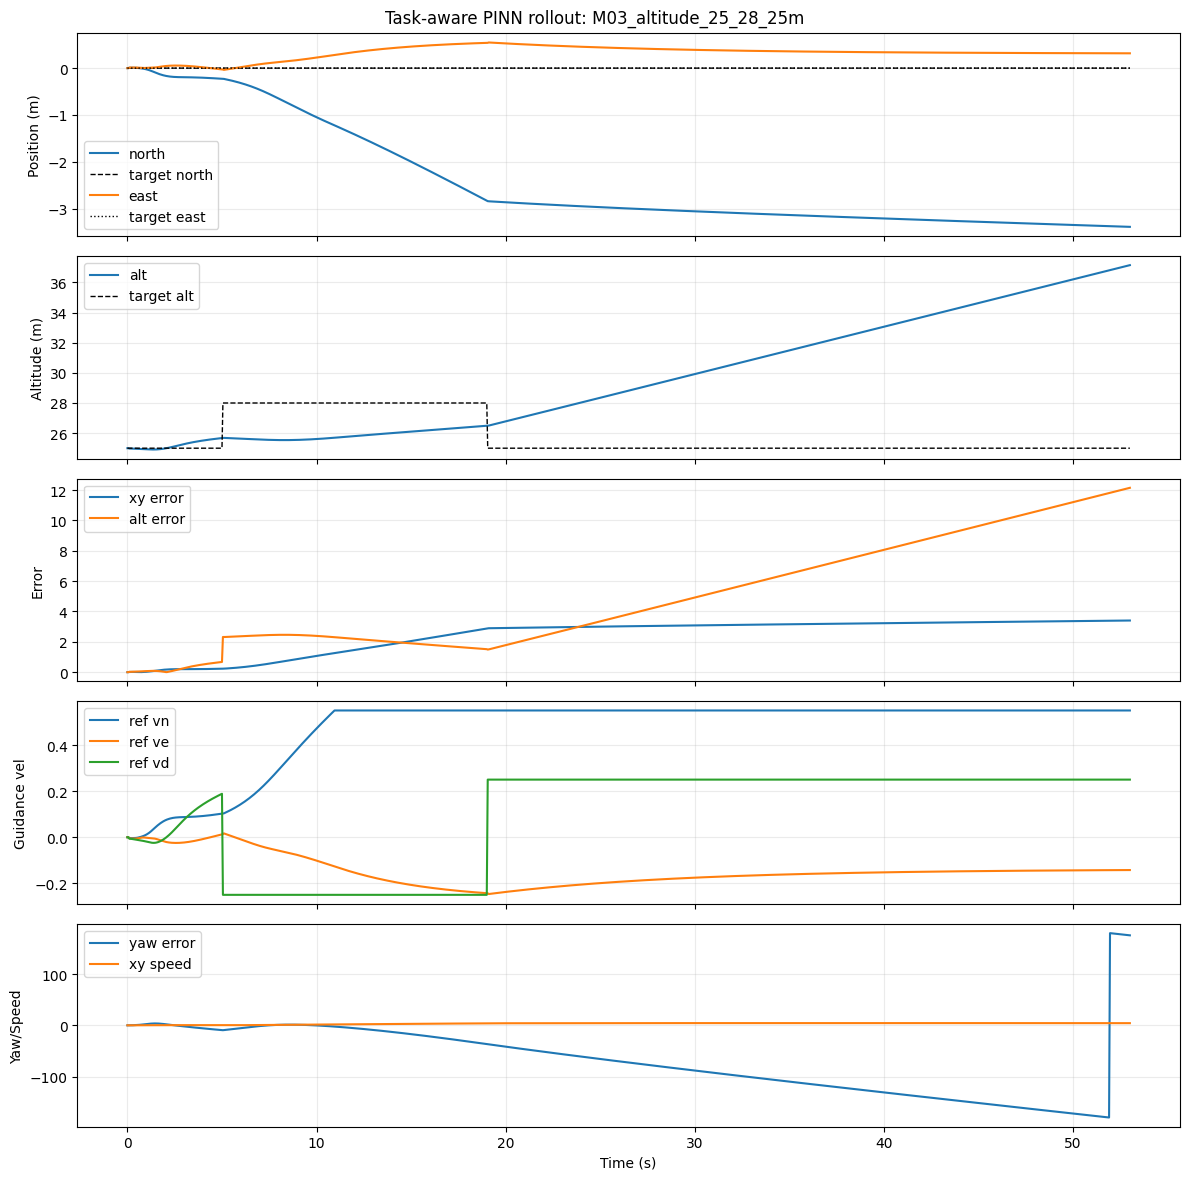

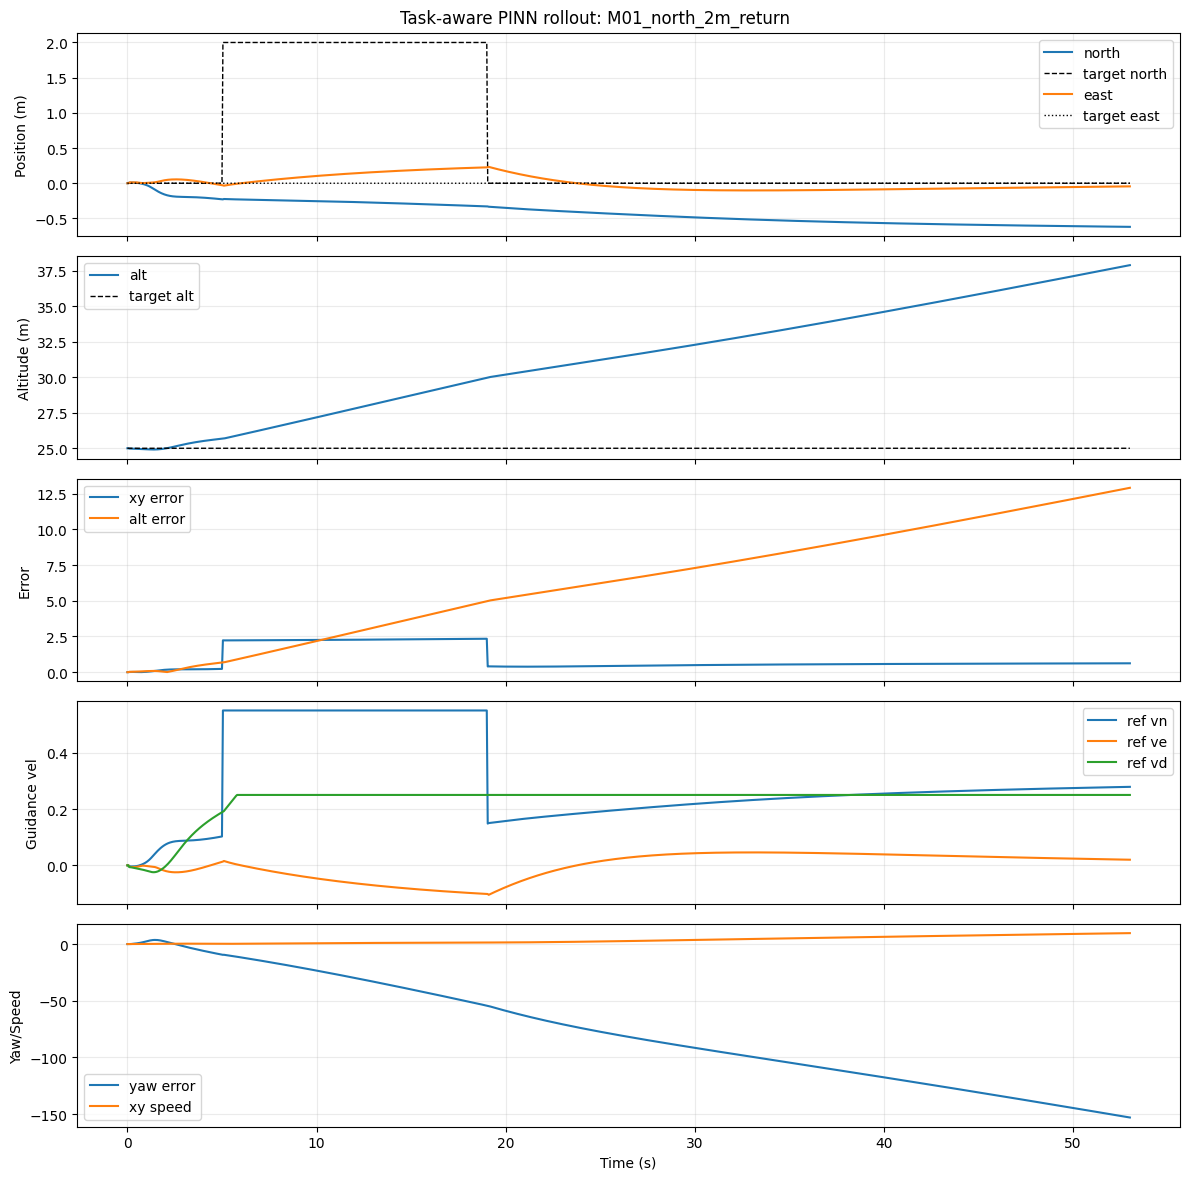

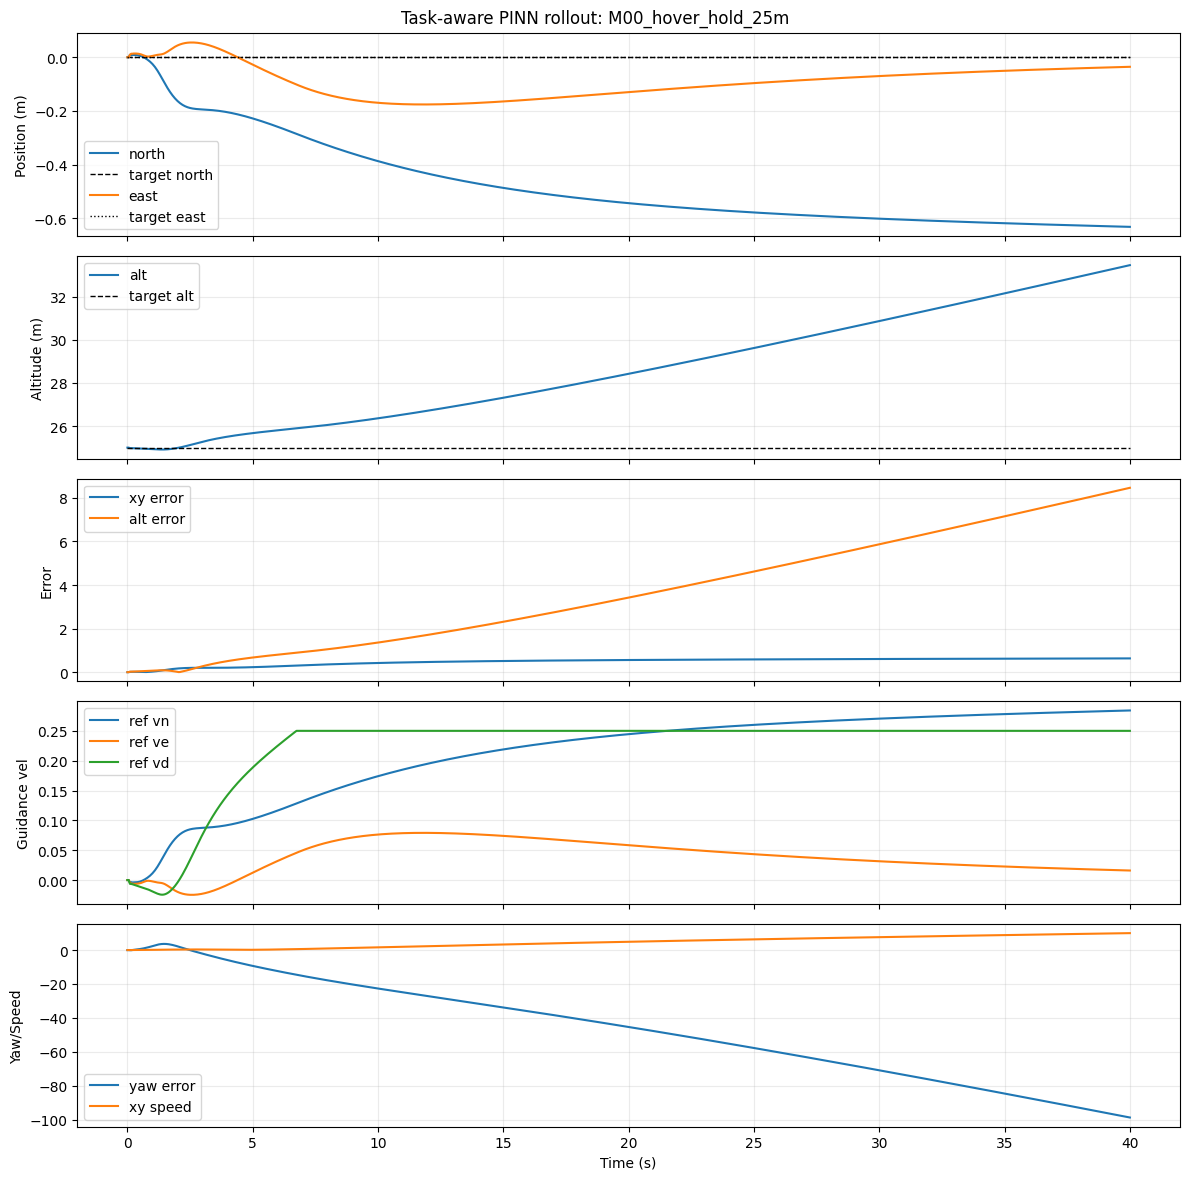

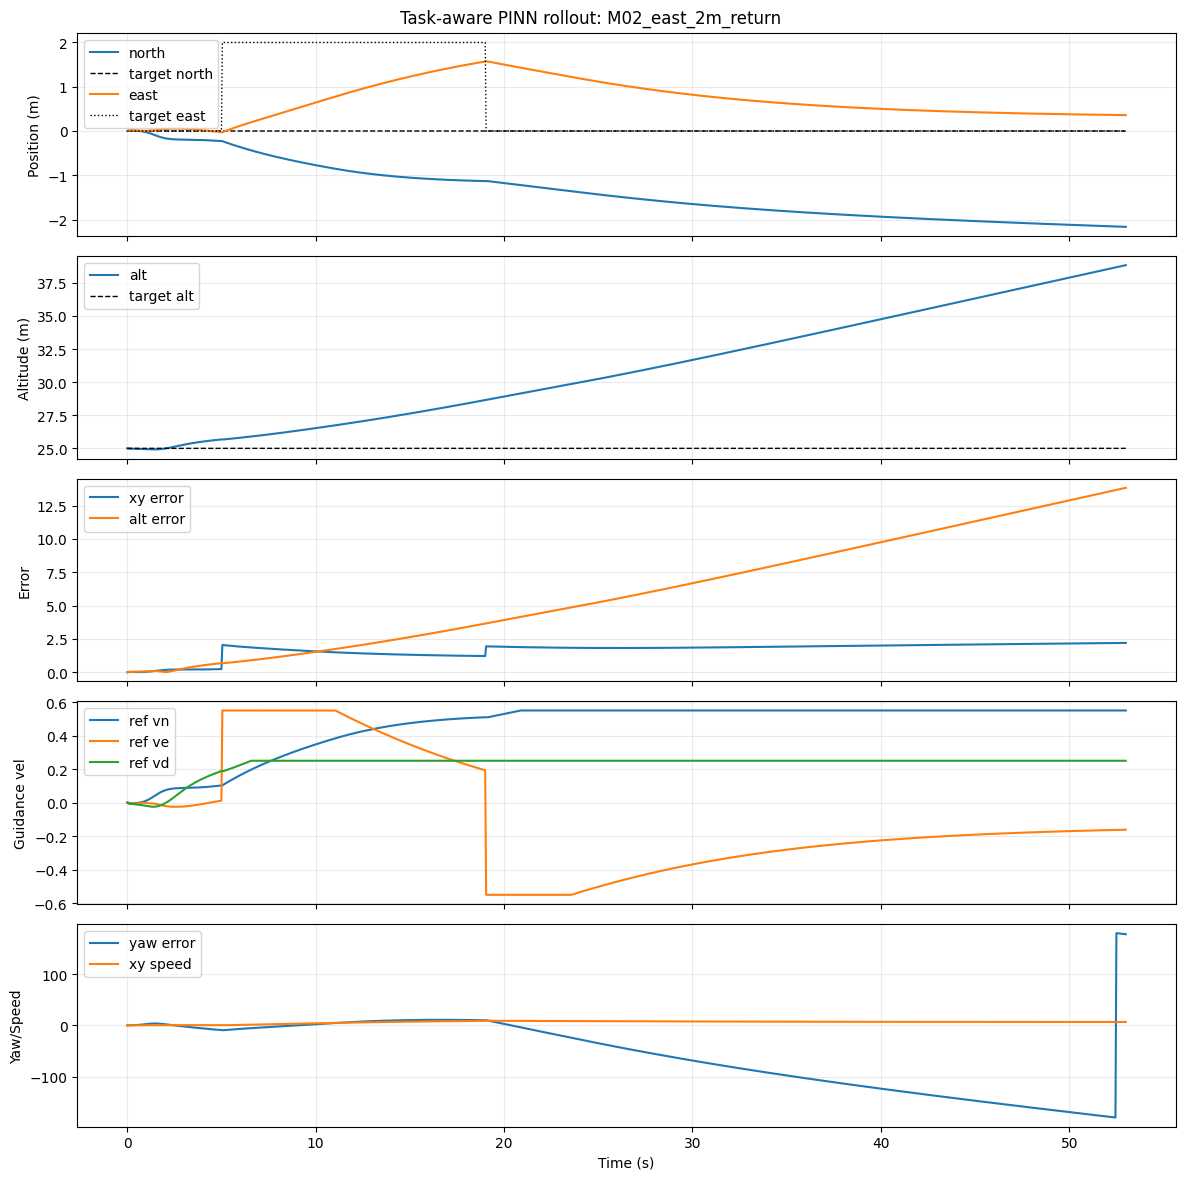

In [14]:
def plot_task_rollout(log, title=None):
    fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
    t = log['time_s'].values
    axes[0].plot(t, log['north_m'], label='north')
    axes[0].plot(t, log['target_north_m'], 'k--', lw=1, label='target north')
    axes[0].plot(t, log['east_m'], label='east')
    axes[0].plot(t, log['target_east_m'], 'k:', lw=1, label='target east')
    axes[0].set_ylabel('Position (m)')
    axes[1].plot(t, log['alt_m'], label='alt')
    axes[1].plot(t, log['target_alt_m'], 'k--', lw=1, label='target alt')
    axes[1].set_ylabel('Altitude (m)')
    axes[2].plot(t, log['pos_err_m'], label='xy error')
    axes[2].plot(t, np.abs(log['alt_err_m']), label='alt error')
    axes[2].set_ylabel('Error')
    axes[3].plot(t, log['ref_vn_m_s'], label='ref vn')
    axes[3].plot(t, log['ref_ve_m_s'], label='ref ve')
    axes[3].plot(t, log['ref_vd_m_s'], label='ref vd')
    axes[3].set_ylabel('Guidance vel')
    axes[4].plot(t, log['yaw_err_deg'], label='yaw error')
    axes[4].plot(t, log['speed_xy_m_s'], label='xy speed')
    axes[4].set_ylabel('Yaw/Speed')
    axes[4].set_xlabel('Time (s)')
    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.legend(loc='best')
    fig.suptitle(title or str(log['task'].iloc[0]))
    plt.tight_layout()
    return fig

for task_name in mission_metrics['task'].head(4):
    fig = plot_task_rollout(rollout_log[rollout_log['task'].eq(task_name)], title=f'Task-aware PINN rollout: {task_name}')
    plt.show()


In [15]:
RUN_STAMP = time.strftime('%Y%m%d_%H%M%S')
if Path('/content/drive/MyDrive').exists():
    SAVE_ROOT = Path('/content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_task_aware_rollout_simulator_v1')
else:
    SAVE_ROOT = Path('/content/px4_phase1_task_aware_rollout_simulator_v1')
SAVE_DIR = SAVE_ROOT / RUN_STAMP
SAVE_DIR.mkdir(parents=True, exist_ok=True)
rollout_log.to_csv(SAVE_DIR / 'task_aware_pinn_rollout_log_v1.csv', index=False)
mission_metrics.to_csv(SAVE_DIR / 'task_aware_pinn_mission_metrics_v1.csv', index=False)
with open(SAVE_DIR / 'task_aware_rollout_config_v1.json', 'w') as f:
    json.dump({
        'revision': NOTEBOOK_REVISION,
        'checkpoint': str(CKPT_PATH),
        'dataset_dir': str(DATASET_DIR),
        'dt': DT,
        'guidance': {
            'kp_pos': GUIDANCE_KP_POS,
            'kp_alt': GUIDANCE_KP_ALT,
            'kp_yaw': GUIDANCE_KP_YAW,
            'max_vxy': GUIDANCE_MAX_VXY_M_S,
            'max_vd': GUIDANCE_MAX_VD_M_S,
        },
        'scope': 'PX4 standard VTOL multicopter closed-loop task-level rollout only; fixed-wing/transition mode is excluded.',
    }, f, indent=2)
print('saved:', SAVE_DIR)


saved: /content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_task_aware_rollout_simulator_v1/20260510_065020
